# Baby Shopper Profiling — Unified Pipeline (v3)

**What changed from v2:**
- Binge-rest logic fully replaced with **Stockpile Repeat Detection** — cleaner definition: bought in bulk, went quiet for ≥30 days, then bought in bulk again
- All references to `binge_rest_ratio`, `avg_cooldown_days`, `can_binge_rest` removed from clustering features and output columns
- Episode detection code removed entirely — no longer needed
- `avg_episode_units` replaced with `avg_day_units` (mean units per active day) as a volume signal
- All other fixes from v2 retained: journey stage map, OTS cluster naming, win-back leakage warning, consistent population filters

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83', '#F46D43']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'figure.titlesize': 13})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Constants ──────────────────────────────────────────────────────────────────
BULK_PERCENTILE    = 0.90   # p90 of daily units = bulk purchase day threshold
STOCKPILE_GAP      = 30     # min days between two bulk days to count as a restock
OBSERVATION_MONTHS = 12
RANDOM_STATE       = 42

# Journey stage map — covers all 26 subdepartments
STAGE_MAP = {
    'toiletries':                       'Daily Care',
    'personal care':                    'Daily Care',
    'diapers':                          'Daily Care',
    'disposable diapers':               'Daily Care',
    'newborn essential 0-12mos':        'Early Care',
    'nursing & feeding':                'Early Care',
    'linen':                            'Early Care',
    'baby girl fashion 0-24 mos':       'Apparel',
    'baby boy fashion 0-24 mos':        'Apparel',
    'toddler boys casual':              'Apparel',
    'toddler girls casual apparel':     'Apparel',
    'toddler boys sleepwear':           'Apparel',
    'toddler girls sleepwear':          'Apparel',
    'toddler boys seasonal':            'Apparel',
    'toddler girls seasonal':           'Apparel',
    'toddler boys fashion collection':  'Apparel',
    'toddler girls fashion':            'Apparel',
    'infant shoes':                     'Apparel',
    'branded apparel':                  'Apparel',
    'carriers & wheeled goods':         'Mobility',
    'furniture':                        'Mobility',
    'furnishings':                      'Mobility',
    'food and supplements':             'Growth',
    'baby c + o':                       'Nursery',
    'toys':                             'Play & Development',
}

print(f"Bulk threshold percentile : p{int(BULK_PERCENTILE*100)}")
print(f"Stockpile gap threshold   : {STOCKPILE_GAP} days")
print("Setup complete.")

Bulk threshold percentile : p90
Stockpile gap threshold   : 30 days
Setup complete.


---
## 2. Data Loading & Cleaning

In [2]:
raw = pd.read_parquet(r"C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet")
print(f"Raw shape: {raw.shape}")

raw["header_tran_date"] = raw["header_tran_date"].str.replace("Sept", "Sep", case=False)
for col in ['department_cleaned', 'subdepartment_cleaned', 'subclass']:
    raw[col] = raw[col].str.lower().str.strip()

raw['date'] = pd.to_datetime(raw['header_tran_date'], format='%d %b %Y', errors='coerce')
print(f"Unparseable dates: {raw['date'].isna().sum():,}")
raw = raw.dropna(subset=['date', 'gcr_persistent_id'])

PROMO_FILTERS = [
    ('subclass',              'md promo'),
    ('subdepartment_cleaned', 'iw promotions'),
    ('subdepartment_cleaned', 'iaf clearance'),
    ('subdepartment_cleaned', 'iaf promotions'),
]
before = len(raw)
for col, val in PROMO_FILTERS:
    raw = raw[raw[col] != val]
print(f"Removed {before - len(raw):,} promo/clearance rows")

SNAPSHOT_DATE = raw['date'].max()
WINDOW_START  = SNAPSHOT_DATE - pd.DateOffset(months=OBSERVATION_MONTHS)
df = raw[raw['date'] >= WINDOW_START].copy()

print(f"\nObservation window : {WINDOW_START.date()} → {SNAPSHOT_DATE.date()}")
print(f"Rows in window     : {len(df):,}")
print(f"Unique customers   : {df['gcr_persistent_id'].nunique():,}")
print(f"Unique subdepts    : {df['subdepartment_cleaned'].nunique()}")

Raw shape: (8320948, 7)
Unparseable dates: 0
Removed 661,715 promo/clearance rows

Observation window : 2024-12-31 → 2025-12-31
Rows in window     : 7,659,233
Unique customers   : 1,483,837
Unique subdepts    : 26


In [3]:
df['customer_id'] = pd.factorize(df['gcr_persistent_id'])[0]
df['year_month']  = df['date'].dt.to_period('M')
df = df.sort_values(['customer_id', 'date']).reset_index(drop=True)
print(f"Final working dataset: {df.shape}")

Final working dataset: (7659233, 10)


---
## 3. Daily Aggregation & Balanced Monthly Panel

In [4]:
# ── Daily aggregation ─────────────────────────────────────────────────────────
daily = (
    df.groupby(['customer_id', 'date'])
      .agg(
          day_transactions      = ('date',                  'count'),
          day_units             = ('total_units',           'sum'),
          day_sales             = ('total_sales',           'sum'),
          distinct_subdepts_day = ('subdepartment_cleaned', 'nunique'),
      )
      .reset_index()
)
daily['year_month'] = daily['date'].dt.to_period('M')

# ── Monthly aggregation ───────────────────────────────────────────────────────
monthly_raw = (
    daily.groupby(['customer_id', 'year_month'])
         .agg(
             total_transactions     = ('day_transactions',      'sum'),
             total_units            = ('day_units',             'sum'),
             total_spend            = ('day_sales',             'sum'),
             days_active_in_month   = ('date',                  'count'),
             last_purchase_date     = ('date',                  'max'),
             distinct_subdept_count = ('distinct_subdepts_day', 'max'),
         )
         .reset_index()
)

# ── Balanced panel (every customer × every month, zeros for inactive months) ──
all_months    = pd.period_range(df['year_month'].min(), df['year_month'].max(), freq='M')
all_customers = df['customer_id'].unique()
panel_index   = pd.MultiIndex.from_product(
    [all_customers, all_months], names=['customer_id', 'year_month']
)
panel = pd.DataFrame(index=panel_index).reset_index()
panel = panel.merge(monthly_raw, on=['customer_id', 'year_month'], how='left')

fill_zero = ['total_transactions', 'total_units', 'total_spend',
             'days_active_in_month', 'distinct_subdept_count']
panel[fill_zero] = panel[fill_zero].fillna(0)
panel['is_active'] = (panel['total_transactions'] > 0).astype(int)

print(f"Balanced panel: {panel.shape[0]:,} rows | "
      f"{len(all_customers):,} customers × {len(all_months)} months")

Balanced panel: 17,806,044 rows | 1,483,837 customers × 12 months


---
## 4. Temporal & Gap Features

In [5]:
# ── Inter-purchase gap statistics ─────────────────────────────────────────────
active_days = (
    daily[['customer_id', 'date']].drop_duplicates()
         .sort_values(['customer_id', 'date'])
)
active_days['gap_days'] = active_days.groupby('customer_id')['date'].diff().dt.days

gap_stats = (
    active_days.groupby('customer_id')['gap_days']
               .agg(
                   avg_gap_days    = 'mean',
                   median_gap_days = 'median',
                   std_gap_days    = 'std',
                   min_gap_days    = 'min',
                   max_gap_days    = 'max',
               )
               .reset_index()
)
gap_stats['purchase_regularity_cv'] = (
    gap_stats['std_gap_days'] / gap_stats['avg_gap_days'].clip(lower=0.01)
)

# ── Activity span & recency ───────────────────────────────────────────────────
span = (
    df.groupby('customer_id')['date']
      .agg(first_purchase='min', last_purchase='max')
      .reset_index()
)
span['activity_span_days']       = (span['last_purchase'] - span['first_purchase']).dt.days
span['days_since_last_purchase'] = (SNAPSHOT_DATE - span['last_purchase']).dt.days

active_months_count = (
    panel[panel['is_active'] == 1]
         .groupby('customer_id')['year_month']
         .nunique().rename('active_months').reset_index()
)
span = span.merge(active_months_count, on='customer_id', how='left')
span['active_months']      = span['active_months'].fillna(1)
span['engagement_density'] = span['active_months'] / len(all_months)

# ── Days to second purchase (early return signal) ─────────────────────────────
active_days_sorted = active_days.sort_values(['customer_id', 'date']).copy()
active_days_sorted['_rn'] = active_days_sorted.groupby('customer_id').cumcount()
first_two = active_days_sorted[active_days_sorted['_rn'] <= 1].drop(columns='_rn')
first_two_gap = (
    first_two[first_two.groupby('customer_id')['date'].transform('count') > 1]
    .groupby('customer_id')['gap_days'].last()
    .rename('days_to_second_purchase').reset_index()
)
all_custs     = pd.DataFrame({'customer_id': active_days['customer_id'].unique()})
first_two_gap = all_custs.merge(first_two_gap, on='customer_id', how='left')
first_two_gap['is_one_time_buyer'] = first_two_gap['days_to_second_purchase'].isna().astype(int)

print(f"One-time buyers: {first_two_gap['is_one_time_buyer'].sum():,} "
      f"({first_two_gap['is_one_time_buyer'].mean()*100:.1f}%)")

One-time buyers: 854,617 (57.6%)


In [6]:
# ── Month-over-month spend delta & volatility ─────────────────────────────────
panel = panel.sort_values(['customer_id', 'year_month'])
panel['delta_total_spend']        = panel.groupby('customer_id')['total_spend'].diff()
panel['delta_total_transactions'] = panel.groupby('customer_id')['total_transactions'].diff()
panel['spend_volatility_3m'] = (
    panel.groupby('customer_id', group_keys=False)['total_spend']
         .rolling(3, min_periods=2).std()
         .reset_index(level=0, drop=True)
)
print("Panel delta features added.")

Panel delta features added.


---
## 5. Bulk Detection & Stockpile Repeat Detection

**Replaces binge-rest episode logic entirely.**

Definition of a stockpile repeat shopper:  
> Had at least 2 bulk purchase days (≥ p90 units in a single day) separated by at least `STOCKPILE_GAP` days.

This directly answers: *who buys in bulk, goes quiet, then buys in bulk again?*  
No relative medians. No episode clustering. Just concrete observable behaviour.

In [7]:
# ── Step 1: Identify bulk purchase days ───────────────────────────────────────
bulk_threshold = daily['day_units'].quantile(BULK_PERCENTILE)
daily['is_bulk_day'] = (daily['day_units'] >= bulk_threshold).astype(int)

# ── Step 2: Overall bulk summary per customer ─────────────────────────────────
bulk = (
    daily.groupby('customer_id')
         .agg(
             bulk_score     = ('day_units',   'mean'),   # avg daily units
             avg_day_units  = ('day_units',   'mean'),   # same, explicit name
             is_bulk        = ('is_bulk_day', 'max'),    # ever had a bulk day
             bulk_day_count = ('is_bulk_day', 'sum'),    # total bulk days
             max_day_units  = ('day_units',   'max'),
         )
         .reset_index()
)

print(f"Bulk threshold (p{int(BULK_PERCENTILE*100)}): {bulk_threshold:.0f} units per shopping day")
print(f"Customers with ≥1 bulk day: {bulk['is_bulk'].sum():,} ({bulk['is_bulk'].mean()*100:.1f}%)")

Bulk threshold (p90): 6 units per shopping day
Customers with ≥1 bulk day: 271,586 (18.3%)


In [8]:
# ── Step 3: Stockpile repeat detection ───────────────────────────────────────
# Isolate all bulk days, sorted by customer and date
bulk_days = (
    daily[daily['is_bulk_day'] == 1][['customer_id', 'date', 'day_units']]
    .copy()
    .sort_values(['customer_id', 'date'])
    .reset_index(drop=True)
)

# Gap between consecutive bulk days for the same customer
bulk_days['prev_bulk_date']      = bulk_days.groupby('customer_id')['date'].shift(1)
bulk_days['gap_since_prev_bulk'] = (bulk_days['date'] - bulk_days['prev_bulk_date']).dt.days

# A restock event = a bulk day that follows a significant rest (gap ≥ STOCKPILE_GAP)
bulk_days['is_restock'] = (
    bulk_days['gap_since_prev_bulk'] >= STOCKPILE_GAP
).astype(int)

# Aggregate to customer level
stockpile_stats = (
    bulk_days.groupby('customer_id')
             .agg(
                 total_bulk_days      = ('date',               'count'),
                 stockpile_events     = ('is_restock',         'sum'),
                 avg_restock_gap_days = ('gap_since_prev_bulk','mean'),
                 max_restock_gap_days = ('gap_since_prev_bulk','max'),
             )
             .reset_index()
)

# Binary flag: had at least 1 confirmed restock (2+ bulk days with gap)
stockpile_stats['is_stockpile_shopper'] = (
    stockpile_stats['stockpile_events'] >= 1
).astype(int)

# Fill NaN for customers with zero bulk days (they won't appear in stockpile_stats)
# We'll handle this during the merge with fillna

n_stockpilers = stockpile_stats['is_stockpile_shopper'].sum()
n_multi_bulk  = (stockpile_stats['total_bulk_days'] >= 2).sum()
n_bulk_total  = len(stockpile_stats)  # customers with ≥1 bulk day

print(f"Stockpile gap threshold          : ≥{STOCKPILE_GAP} days between bulk days")
print(f"Customers with ≥1 bulk day       : {n_bulk_total:,}")
print(f"Customers with ≥2 bulk days      : {n_multi_bulk:,}")
print(f"Stockpile shoppers (≥2 bulk+gap) : {n_stockpilers:,} "
      f"({n_stockpilers/n_bulk_total*100:.1f}% of bulk buyers)")

if n_stockpilers == 0:
    print("\n⚠ Still 0. The bulk threshold may be too high.")
    print(f"  Trying p85 instead of p90...")
    alt_threshold = daily['day_units'].quantile(0.85)
    alt_bulk = daily[daily['day_units'] >= alt_threshold]
    print(f"  At p85 ({alt_threshold:.0f} units): {alt_bulk['customer_id'].nunique():,} customers have a bulk day")
    print("  Consider setting BULK_PERCENTILE = 0.85 and re-running from cell 5.")
else:
    stk = stockpile_stats[stockpile_stats['is_stockpile_shopper'] == 1]
    print(f"\n=== Stockpile Shopper Profile ===")
    print(f"  Avg restock events per stockpiler : {stk['stockpile_events'].mean():.1f}")
    print(f"  Median gap between bulk days      : {stk['avg_restock_gap_days'].median():.0f} days")
    print(f"  Max gap between bulk days (median): {stk['max_restock_gap_days'].median():.0f} days")

Stockpile gap threshold          : ≥30 days between bulk days
Customers with ≥1 bulk day       : 271,586
Customers with ≥2 bulk days      : 76,025
Stockpile shoppers (≥2 bulk+gap) : 64,063 (23.6% of bulk buyers)

=== Stockpile Shopper Profile ===
  Avg restock events per stockpiler : 1.6
  Median gap between bulk days      : 78 days
  Max gap between bulk days (median): 111 days


---
## 6. Category Features

In [9]:
# ── Share of wallet & breadth ─────────────────────────────────────────────────
subdept_cust = (
    df.groupby(['customer_id', 'subdepartment_cleaned'])
      .agg(subdept_units=('total_units', 'sum'), subdept_sales=('total_sales', 'sum'))
      .reset_index()
)
cust_totals = (
    df.groupby('customer_id')
      .agg(lifetime_units=('total_units', 'sum'), lifetime_sales=('total_sales', 'sum'))
      .reset_index()
)
subdept_cust = subdept_cust.merge(cust_totals, on='customer_id')
subdept_cust['subdept_unit_share']  = (
    subdept_cust['subdept_units'] / subdept_cust['lifetime_units'].clip(lower=1)
)
subdept_cust['subdept_sales_share'] = (
    subdept_cust['subdept_sales'] / subdept_cust['lifetime_sales'].clip(lower=0.01)
)

top_subdept = (
    subdept_cust.sort_values('subdept_units', ascending=False)
                .drop_duplicates('customer_id')
                [['customer_id', 'subdepartment_cleaned', 'subdept_unit_share']]
                .rename(columns={
                    'subdepartment_cleaned': 'top_subdept',
                    'subdept_unit_share':    'top_subdept_share'
                })
)

subdept_breadth = (
    subdept_cust.groupby('customer_id')['subdepartment_cleaned']
                .nunique().rename('distinct_subdept_count').reset_index()
)

share_wide = (
    subdept_cust.pivot_table(
        index='customer_id', columns='subdepartment_cleaned',
        values='subdept_unit_share', aggfunc='sum', fill_value=0
    )
)
share_wide.columns = ['sow__' + c.replace(' ', '_') for c in share_wide.columns]
share_wide = share_wide.reset_index()

print("Share of wallet & breadth computed.")

Share of wallet & breadth computed.


In [10]:
# ── New subdepartment adoption (monthly) ──────────────────────────────────────
cust_month_subdept = (
    df.groupby(['customer_id', 'year_month', 'subdepartment_cleaned'])
      .size().reset_index(name='_n')[['customer_id', 'year_month', 'subdepartment_cleaned']]
)
cust_month_subdept['year_month_int'] = (
    cust_month_subdept['year_month'].dt.year * 12
    + cust_month_subdept['year_month'].dt.month
)
prior = cust_month_subdept.copy()
prior['year_month_int'] = prior['year_month_int'] + 1
new_subdept = cust_month_subdept.merge(
    prior[['customer_id', 'year_month_int', 'subdepartment_cleaned']],
    on=['customer_id', 'year_month_int', 'subdepartment_cleaned'],
    how='left', indicator=True
)
new_subdept['is_new'] = (new_subdept['_merge'] == 'left_only').astype(int)
new_subdept_avg = (
    new_subdept.groupby(['customer_id', 'year_month'])['is_new']
               .sum().reset_index(name='new_subdept_count')
               .groupby('customer_id')['new_subdept_count']
               .mean().rename('avg_new_subdept_per_month').reset_index()
)

# ── Category change magnitude ─────────────────────────────────────────────────
monthly_subdept_share = (
    df.groupby(['customer_id', 'year_month', 'subdepartment_cleaned'])['total_units']
      .sum().reset_index(name='subdept_units')
)
monthly_subdept_share = monthly_subdept_share.merge(
    panel[['customer_id', 'year_month', 'total_units']],
    on=['customer_id', 'year_month'], how='left'
)
monthly_subdept_share['share'] = (
    monthly_subdept_share['subdept_units']
    / monthly_subdept_share['total_units'].clip(lower=1)
)
monthly_subdept_share = monthly_subdept_share.sort_values(
    ['customer_id', 'subdepartment_cleaned', 'year_month']
)
monthly_subdept_share['delta_share'] = (
    monthly_subdept_share
    .groupby(['customer_id', 'subdepartment_cleaned'])['share'].diff()
)
monthly_subdept_share['abs_delta_share'] = monthly_subdept_share['delta_share'].abs()
avg_change_magnitude = (
    monthly_subdept_share.groupby(['customer_id', 'year_month'])['abs_delta_share']
                         .sum().reset_index(name='change_magnitude')
                         .groupby('customer_id')['change_magnitude']
                         .mean().rename('avg_change_magnitude').reset_index()
)

print("Category journey signals computed.")

Category journey signals computed.


---
## 7. Assemble Master Profile

In [11]:
# ── Panel-level summary ───────────────────────────────────────────────────────
panel_summary = (
    panel.groupby('customer_id')
         .agg(
             total_transactions_12m   = ('total_transactions', 'sum'),
             total_units_12m          = ('total_units',        'sum'),
             total_spend_12m          = ('total_spend',        'sum'),
             avg_monthly_transactions = ('total_transactions', 'mean'),
             avg_monthly_spend        = ('total_spend',        'mean'),
             spend_volatility_avg     = ('spend_volatility_3m','mean'),
             max_monthly_spend        = ('total_spend',        'max'),
         )
         .reset_index()
)
active_panel_spend = (
    panel[panel['is_active'] == 1]
         .groupby('customer_id')['total_spend']
         .mean().rename('avg_spend_per_visit').reset_index()
)
panel_summary = panel_summary.merge(active_panel_spend, on='customer_id', how='left')

# ── Merge all feature tables ──────────────────────────────────────────────────
profile = (
    panel_summary
    .merge(span,                 on='customer_id', how='left')
    .merge(gap_stats,            on='customer_id', how='left')
    .merge(first_two_gap,        on='customer_id', how='left')
    .merge(stockpile_stats,      on='customer_id', how='left')   # replaces binge_rest
    .merge(bulk,                 on='customer_id', how='left')
    .merge(top_subdept,          on='customer_id', how='left')
    .merge(subdept_breadth,      on='customer_id', how='left')
    .merge(new_subdept_avg,      on='customer_id', how='left')
    .merge(avg_change_magnitude, on='customer_id', how='left')
    .merge(share_wide,           on='customer_id', how='left')
)

# Fill NaN for customers with no bulk days (they won't appear in stockpile_stats)
for col in ['total_bulk_days', 'stockpile_events', 'is_stockpile_shopper']:
    profile[col] = profile[col].fillna(0).astype(int)
for col in ['avg_restock_gap_days', 'max_restock_gap_days']:
    profile[col] = profile[col].fillna(0)

profile['shopper_type'] = np.where(
    profile['is_one_time_buyer'] == 1, 'One-Time', 'Repeat'
)
profile['journey_stage'] = profile['top_subdept'].map(STAGE_MAP).fillna('Other')

other_pct = (profile['journey_stage'] == 'Other').mean() * 100
print(f"Master profile: {profile.shape[0]:,} customers × {profile.shape[1]} features")
print(f"Stockpile shoppers in profile: {profile['is_stockpile_shopper'].sum():,} "
      f"({profile['is_stockpile_shopper'].mean()*100:.1f}% of all shoppers)")
print(f"Journey stage 'Other': {other_pct:.1f}%")
print(profile['journey_stage'].value_counts())

Master profile: 1,483,837 customers × 66 features
Stockpile shoppers in profile: 64,063 (4.3% of all shoppers)
Journey stage 'Other': 17.8%
journey_stage
Apparel               546893
Daily Care            296758
Other                 264153
Early Care            204693
Nursery               111121
Play & Development     31351
Mobility               17058
Growth                 11810
Name: count, dtype: int64


---
## 8. Category Transition Matrix

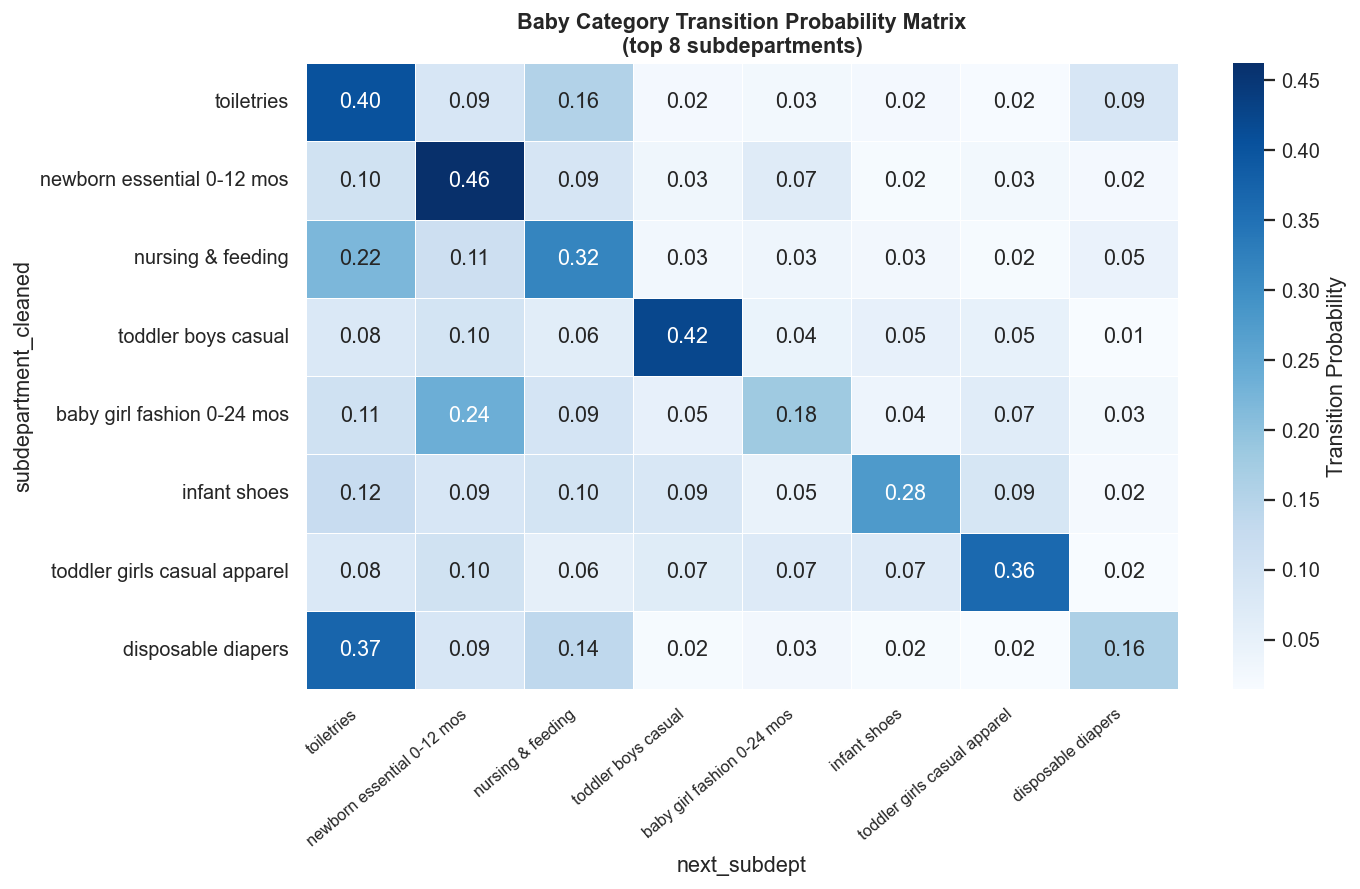

In [12]:
df_sorted = df.sort_values(['customer_id', 'date'])
df_sorted['next_subdept'] = df_sorted.groupby('customer_id')['subdepartment_cleaned'].shift(-1)

transitions = (
    df_sorted.dropna(subset=['next_subdept'])
             .groupby(['subdepartment_cleaned', 'next_subdept'])
             .size().reset_index(name='count')
)
from_totals = transitions.groupby('subdepartment_cleaned')['count'].sum().rename('from_total')
transitions = transitions.join(from_totals, on='subdepartment_cleaned')
transitions['prob'] = transitions['count'] / transitions['from_total']

top_subdepts = df['subdepartment_cleaned'].value_counts().head(8).index.tolist()
hm_data = (
    transitions[
        transitions['subdepartment_cleaned'].isin(top_subdepts) &
        transitions['next_subdept'].isin(top_subdepts)
    ]
    .pivot(index='subdepartment_cleaned', columns='next_subdept', values='prob')
    .fillna(0)
    .reindex(index=top_subdepts, columns=top_subdepts, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(hm_data, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Transition Probability'})
ax.set_title('Baby Category Transition Probability Matrix\n(top 8 subdepartments)',
             fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('13_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Overall Shopper Clustering

In [13]:
# is_stockpile_shopper replaces binge_rest_ratio
# avg_day_units replaces avg_episode_units
# avg_cooldown_days removed entirely
CLUSTER_FEATURES = [
    'total_transactions_12m',
    'total_spend_12m',
    'avg_gap_days',
    'activity_span_days',
    'days_since_last_purchase',
    'is_stockpile_shopper',   # replaces binge_rest_ratio
    'avg_day_units',          # replaces avg_episode_units
    'bulk_score',
    'distinct_subdept_count',
    'purchase_regularity_cv',
    'engagement_density',
]

cluster_df = (
    profile[['customer_id', 'shopper_type'] + CLUSTER_FEATURES]
    .dropna(subset=CLUSTER_FEATURES)
    .copy()
)
for col in CLUSTER_FEATURES:
    lo, hi = cluster_df[col].quantile([0.01, 0.99])
    cluster_df[col] = cluster_df[col].clip(lo, hi)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[CLUSTER_FEATURES])
print(f"Clustering dataset: {cluster_df.shape[0]:,} customers, {len(CLUSTER_FEATURES)} features")

Clustering dataset: 360,188 customers, 11 features


In [14]:
K_RANGE     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(
        X_scaled, lbl,
        sample_size=min(5000, len(X_scaled)),
        random_state=RANDOM_STATE
    )
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

best_k = list(K_RANGE)[np.argmax(silhouettes)]
print(f"\nStatistically optimal k = {best_k}")
print("NOTE: Silhouette ~0.2-0.3 is expected — clusters are directional bands, not hard separations.")

  k=2  inertia=2,776,497  silhouette=0.3826
  k=3  inertia=2,371,564  silhouette=0.2024
  k=4  inertia=2,091,184  silhouette=0.1942
  k=5  inertia=1,850,349  silhouette=0.2053
  k=6  inertia=1,717,879  silhouette=0.1973
  k=7  inertia=1,595,050  silhouette=0.2038
  k=8  inertia=1,491,282  silhouette=0.1956

Statistically optimal k = 2
NOTE: Silhouette ~0.2-0.3 is expected — clusters are directional bands, not hard separations.


In [15]:
K_FINAL  = best_k
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)
profile = profile.merge(cluster_df[['customer_id', 'cluster']], on='customer_id', how='left')

print("Cluster distribution:")
print(profile['cluster'].value_counts().sort_index())

centroids = (
    profile.dropna(subset=['cluster'])
           .groupby('cluster')[CLUSTER_FEATURES].median()
)
centroids['n']   = profile['cluster'].value_counts().sort_index()
centroids['pct'] = (centroids['n'] / len(profile) * 100).round(1)
print("\n=== Cluster Centroids (median) ===")
centroids.T

Cluster distribution:
cluster
0.000    282879
1.000     77309
Name: count, dtype: int64

=== Cluster Centroids (median) ===


cluster,0.000,1.000
total_transactions_12m,7.000,27.000
total_spend_12m,3555.000,17318.000
avg_gap_days,60.000,32.900
activity_span_days,217.000,289.000
days_since_last_purchase,32.000,17.000
is_stockpile_shopper,0.000,1.000
avg_day_units,2.200,4.800
bulk_score,2.200,4.800
distinct_subdept_count,4.000,8.000
purchase_regularity_cv,0.784,0.807


In [16]:
CLUSTER_NAMES = {}
for c in sorted(profile['cluster'].dropna().unique()):
    c        = int(c)
    freq     = centroids.loc[c, 'total_transactions_12m']
    gap      = centroids.loc[c, 'avg_gap_days']
    stockpile= centroids.loc[c, 'is_stockpile_shopper']
    bulk     = centroids.loc[c, 'bulk_score']
    density  = centroids.loc[c, 'engagement_density']
    units    = centroids.loc[c, 'avg_day_units']

    med_freq     = centroids['total_transactions_12m'].median()
    med_bulk     = centroids['bulk_score'].median()
    med_units    = centroids['avg_day_units'].median()
    med_density  = centroids['engagement_density'].median()

    if stockpile > 0.3 or (units > med_units * 1.3 and bulk > med_bulk * 1.3):
        name = 'High-Volume Buyers'
    elif freq > med_freq * 1.3 and gap < centroids['avg_gap_days'].median():
        name = 'High-Frequency Regulars'
    elif density > med_density:
        name = 'Consistent Engagers'
    else:
        name = 'Moderate Buyers'

    CLUSTER_NAMES[c] = name
    print(f"Cluster {c} ({centroids.loc[c,'pct']:.1f}%) → '{name}'")

profile['segment'] = profile['cluster'].map(CLUSTER_NAMES)

Cluster 0 (19.1%) → 'Moderate Buyers'
Cluster 1 (5.2%) → 'High-Volume Buyers'


---
## 10. Save Phase 1 Outputs

In [17]:
OUTPUT_COLS = [
    'customer_id',
    'total_transactions_12m', 'total_units_12m', 'total_spend_12m',
    'active_months', 'activity_span_days', 'engagement_density',
    'avg_gap_days', 'median_gap_days', 'std_gap_days', 'purchase_regularity_cv',
    'days_since_last_purchase', 'days_to_second_purchase',
    'is_one_time_buyer', 'shopper_type',
    'avg_monthly_spend', 'avg_spend_per_visit', 'max_monthly_spend', 'spend_volatility_avg',
    # Stockpile features (replaces binge-rest)
    'total_bulk_days', 'stockpile_events', 'is_stockpile_shopper',
    'avg_restock_gap_days', 'max_restock_gap_days',
    # Bulk features
    'bulk_score', 'avg_day_units', 'is_bulk', 'bulk_day_count', 'max_day_units',
    # Category
    'top_subdept', 'top_subdept_share', 'distinct_subdept_count',
    'avg_new_subdept_per_month', 'avg_change_magnitude', 'journey_stage',
    # Segments
    'cluster', 'segment',
]
OUTPUT_COLS += [c for c in profile.columns if c.startswith('sow__')]
OUTPUT_COLS  = [c for c in OUTPUT_COLS if c in profile.columns]

id_map = df[['customer_id', 'gcr_persistent_id']].drop_duplicates()
output = (
    profile[OUTPUT_COLS].merge(id_map, on='customer_id', how='left')
    if 'gcr_persistent_id' not in profile.columns
    else profile[OUTPUT_COLS]
)

output.to_parquet('baby_shopper_profiles_phase1.parquet', index=False)
output.to_csv('baby_shopper_profiles_phase1.csv', index=False)
panel.to_parquet('baby_shopper_panel_monthly.parquet', index=False)

seg_card = (
    profile.dropna(subset=['segment'])
           .groupby('segment')
           .agg(
               n_customers          = ('customer_id',           'count'),
               median_transactions  = ('total_transactions_12m','median'),
               median_spend         = ('total_spend_12m',       'median'),
               median_gap_days      = ('avg_gap_days',          'median'),
               median_span_days     = ('activity_span_days',    'median'),
               pct_bulk             = ('is_bulk',               'mean'),
               pct_stockpile        = ('is_stockpile_shopper',  'mean'),
               median_recency       = ('days_since_last_purchase','median'),
           )
)
seg_card['pct_of_base']  = (seg_card['n_customers'] / len(profile) * 100).round(1).astype(str) + '%'
seg_card['pct_bulk']     = (seg_card['pct_bulk'] * 100).round(1).astype(str) + '%'
seg_card['pct_stockpile']= (seg_card['pct_stockpile'] * 100).round(1).astype(str) + '%'
seg_card.to_csv('segment_summary_phase1.csv')

print(f"Saved: baby_shopper_profiles_phase1.parquet ({output.shape[0]:,} × {output.shape[1]})")
print(f"Saved: baby_shopper_panel_monthly.parquet   ({panel.shape[0]:,} rows)")
print(f"Saved: segment_summary_phase1.csv")
print("\n=== Phase 1 Complete ===")
seg_card.T

Saved: baby_shopper_profiles_phase1.parquet (1,483,837 × 64)
Saved: baby_shopper_panel_monthly.parquet   (17,806,044 rows)
Saved: segment_summary_phase1.csv

=== Phase 1 Complete ===


segment,High-Volume Buyers,Moderate Buyers
n_customers,77309,282879
median_transactions,27.000,7.000
median_spend,17318.000,3555.000
median_gap_days,32.900,60.000
median_span_days,289.000,217.000
pct_bulk,96.2%,27.9%
pct_stockpile,73.5%,1.0%
median_recency,17.000,32.000
pct_of_base,5.2%,19.1%


---
## 11. One-Time Shopper Analysis

In [18]:
profile = pd.read_parquet('baby_shopper_profiles_phase1.parquet')
print(f"Full profile: {profile.shape[0]:,} customers")
print(profile['shopper_type'].value_counts())

Full profile: 1,483,837 customers
shopper_type
One-Time    854617
Repeat      629220
Name: count, dtype: int64


In [19]:
# Consistent OTS filter: exactly 1 transaction in 12m
ots = profile[profile['total_transactions_12m'] == 1].copy().reset_index(drop=True)
print(f"One-time shoppers: {len(ots):,}")

# Reload raw transactions for OTS-specific features
raw = pd.read_parquet(
    r'C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet'
)
for col in ['department_cleaned', 'subdepartment_cleaned', 'subclass']:
    raw[col] = raw[col].str.lower().str.strip()
raw['header_tran_date'] = raw['header_tran_date'].str.replace('Sept', 'Sep', regex=False)
raw['date'] = pd.to_datetime(raw['header_tran_date'], format='%d %b %Y', errors='coerce')
raw = raw.dropna(subset=['date', 'gcr_persistent_id'])
for col, val in [
    ('subclass', 'md promo'), ('subdepartment_cleaned', 'iw promotions'),
    ('subdepartment_cleaned', 'iaf clearance'), ('subdepartment_cleaned', 'iaf promotions'),
]:
    raw = raw[raw[col] != val]
SNAPSHOT_DATE = raw['date'].max()
WINDOW_START  = SNAPSHOT_DATE - pd.DateOffset(months=12)
raw           = raw[raw['date'] >= WINDOW_START].copy()
raw['customer_id'] = pd.factorize(raw['gcr_persistent_id'])[0]

ots_ids = set(ots['customer_id'].values)
seq     = (
    raw[raw['customer_id'].isin(ots_ids)]
    .copy()
    .sort_values(['customer_id', 'date'])
    .reset_index(drop=True)
)
print(f"OTS transaction rows: {len(seq):,}")

One-time shoppers: 492,394
OTS transaction rows: 492,394


In [20]:
# ── Visit-level features ──────────────────────────────────────────────────────
visit_stats = (
    seq.groupby('customer_id')
       .agg(
           total_spend      = ('total_sales',           'sum'),
           total_units      = ('total_units',           'sum'),
           category_breadth = ('subdepartment_cleaned', 'nunique'),
           visit_date       = ('date',                  'first'),
       )
       .reset_index()
)
visit_stats['spend_per_unit'] = (
    visit_stats['total_spend'] / visit_stats['total_units'].clip(lower=1)
)

# Top category share
subdept_u = (
    seq.groupby(['customer_id', 'subdepartment_cleaned'])['total_units']
       .sum().reset_index(name='subdept_units')
)
cust_u = seq.groupby('customer_id')['total_units'].sum().reset_index(name='total_units_check')
subdept_u = subdept_u.merge(cust_u, on='customer_id')
subdept_u['unit_share'] = subdept_u['subdept_units'] / subdept_u['total_units_check'].clip(lower=1)
top_cat_share = (
    subdept_u.groupby('customer_id')['unit_share']
             .max().rename('top_category_share').reset_index()
)
top_cat_name = (
    subdept_u.sort_values('unit_share', ascending=False)
             .drop_duplicates('customer_id')
             [['customer_id', 'subdepartment_cleaned']]
             .rename(columns={'subdepartment_cleaned': 'top_category'})
)

# Bulk flag (p90 of OTS visit units)
ots_bulk_threshold = visit_stats['total_units'].quantile(0.90)
visit_stats['is_bulk_visit'] = (visit_stats['total_units'] >= ots_bulk_threshold).astype(int)

# Recency
visit_stats['recency_days'] = (SNAPSHOT_DATE - visit_stats['visit_date']).dt.days
snap_ym = SNAPSHOT_DATE.year * 12 + SNAPSHOT_DATE.month
visit_stats['visit_year_month']  = visit_stats['visit_date'].dt.to_period('M')
visit_stats['visit_month_index'] = (
    snap_ym
    - visit_stats['visit_date'].dt.year * 12
    - visit_stats['visit_date'].dt.month
)

print(f"OTS bulk threshold (p90): {ots_bulk_threshold:.0f} units")
print(f"Bulk visitors: {visit_stats['is_bulk_visit'].sum():,} ({visit_stats['is_bulk_visit'].mean()*100:.1f}%)")

OTS bulk threshold (p90): 2 units
Bulk visitors: 85,689 (17.4%)


In [21]:
# ── Assemble OTS profile ──────────────────────────────────────────────────────
ots = (
    ots
    .merge(
        visit_stats[['customer_id', 'total_spend', 'total_units', 'spend_per_unit',
                     'category_breadth', 'is_bulk_visit', 'recency_days',
                     'visit_month_index', 'visit_date', 'visit_year_month']],
        on='customer_id', how='left'
    )
    .merge(top_cat_share, on='customer_id', how='left')
    .merge(top_cat_name,  on='customer_id', how='left')
)
ots['journey_stage'] = ots['top_category'].map(STAGE_MAP).fillna('Other')

# Rename to avoid column collision with 12m aggregates
if 'total_spend_12m' in ots.columns:
    ots = ots.drop(columns=['total_spend_12m'])
ots = ots.rename(columns={'total_spend': 'visit_spend', 'total_units': 'visit_units'})

OTS_FEATURES = [
    'visit_spend', 'visit_units', 'spend_per_unit', 'category_breadth',
    'top_category_share', 'is_bulk_visit', 'recency_days', 'visit_month_index',
]
print(f"OTS profile: {ots.shape}")

OTS profile: (492394, 74)


In [23]:
# ── OTS clustering ────────────────────────────────────────────────────────────
cluster_input = ots[['customer_id'] + OTS_FEATURES].dropna(subset=OTS_FEATURES).copy()

# Drop 'cluster' col if it already exists from a previous run
ots = ots.drop(columns=['cluster'], errors='ignore')
cluster_input = cluster_input.drop(columns=['cluster'], errors='ignore')

for col in OTS_FEATURES:
    lo, hi = cluster_input[col].quantile([0.01, 0.99])
    cluster_input[col] = cluster_input[col].clip(lo, hi)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_input[OTS_FEATURES])

K_RANGE     = range(2, 9)
silhouettes = []
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    sil = silhouette_score(
        X_scaled, lbl,
        sample_size=min(5000, len(X_scaled)),
        random_state=RANDOM_STATE
    )
    silhouettes.append(sil)
    print(f"  k={k}  silhouette={sil:.4f}")

best_k   = list(K_RANGE)[np.argmax(silhouettes)]
K_FINAL  = best_k
print(f"\nBest k = {best_k}")

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
cluster_input['cluster'] = km_final.fit_predict(X_scaled)
ots = ots.merge(cluster_input[['customer_id', 'cluster']], on='customer_id', how='left')

centroids = cluster_input.groupby('cluster')[OTS_FEATURES].median()
centroids['n']   = ots['cluster'].value_counts().sort_index()
centroids['pct'] = (centroids['n'] / len(ots) * 100).round(1)
print(centroids.T.round(3))

for c, n in ots['cluster'].value_counts().items():
    print(f"  Cluster {c}: {n:,} ({n/len(ots)*100:.1f}%)")

  k=2  silhouette=0.4933
  k=3  silhouette=0.5332
  k=4  silhouette=0.4991
  k=5  silhouette=0.5075
  k=6  silhouette=0.4423
  k=7  silhouette=0.4620
  k=8  silhouette=0.4695

Best k = 3
cluster                    0          1         2
visit_spend          632.000    399.000  4899.000
visit_units            2.000      1.000     1.000
spend_per_unit       299.000    399.000  4699.000
category_breadth       1.000      1.000     1.000
top_category_share     1.000      1.000     1.000
is_bulk_visit          1.000      0.000     0.000
recency_days         136.000    136.000   162.000
visit_month_index      4.000      4.000     5.000
n                  85335.000 395311.000 11748.000
pct                   17.300     80.300     2.400
  Cluster 1: 395,311 (80.3%)
  Cluster 0: 85,335 (17.3%)
  Cluster 2: 11,748 (2.4%)


In [24]:
# ── OTS segment naming ────────────────────────────────────────────────────────
SEGMENT_NAMES = {}

med_spend   = centroids['visit_spend'].median()
med_units   = centroids['visit_units'].median()
med_breadth = centroids['category_breadth'].median()
med_conc    = centroids['top_category_share'].median()
med_recency = centroids['recency_days'].median()
med_spu     = centroids['spend_per_unit'].median()

for c in sorted(ots['cluster'].dropna().unique()):
    c       = int(c)
    spend   = centroids.loc[c, 'visit_spend']
    units   = centroids.loc[c, 'visit_units']
    breadth = centroids.loc[c, 'category_breadth']
    spu     = centroids.loc[c, 'spend_per_unit']
    recency = centroids.loc[c, 'recency_days']
    bulk    = centroids.loc[c, 'is_bulk_visit']

    if bulk >= 0.5 and units > med_units * 1.5:
        name = 'One-Trip Stockpilers'
    elif spend > med_spend * 2.5 and spu > med_spu * 2.0:
        name = 'Premium Single-Visit'
    elif recency > med_recency * 1.5:
        name = 'Distant Lapsed'
    elif spend > med_spend * 1.4 and breadth > med_breadth:
        name = 'High-Value Explorers'
    elif spend > med_spend * 1.3 and centroids.loc[c, 'top_category_share'] > med_conc * 1.2:
        name = 'Focused High-Spenders'
    elif breadth > med_breadth * 1.3 and spend <= med_spend:
        name = 'Curious Browsers'
    elif recency <= med_recency * 0.5:
        name = 'Recent Light Buyers'
    else:
        name = 'Moderate Single-Visit'

    SEGMENT_NAMES[c] = name
    print(f"Cluster {c} ({centroids.loc[c,'pct']:.1f}%) → '{name}'")
    print(f"  spend={spend:.0f}, units={units:.1f}, spu={spu:.0f}, "
          f"breadth={breadth:.0f}, bulk={bulk:.2f}")

ots['segment'] = ots['cluster'].map(SEGMENT_NAMES)

Cluster 0 (17.3%) → 'One-Trip Stockpilers'
  spend=632, units=2.0, spu=299, breadth=1, bulk=1.00
Cluster 1 (80.3%) → 'Moderate Single-Visit'
  spend=399, units=1.0, spu=399, breadth=1, bulk=0.00
Cluster 2 (2.4%) → 'Premium Single-Visit'
  spend=4899, units=1.0, spu=4699, breadth=1, bulk=0.00


---
## 12. Win-Back Scoring Model

In [25]:
# ── Build labelled dataset ────────────────────────────────────────────────────
# Label 1 = became a repeat shopper  |  Label 0 = stayed one-time
repeat_ids = set(profile[profile['shopper_type'] == 'Repeat']['customer_id'].values)
seq_repeat  = raw[raw['customer_id'].isin(repeat_ids)].copy()

first_visit = (
    seq_repeat.groupby('customer_id')['date'].min().reset_index(name='first_date')
)
seq_repeat = seq_repeat.merge(first_visit, on='customer_id')
seq_first  = seq_repeat[seq_repeat['date'] == seq_repeat['first_date']].copy()

first_stats = (
    seq_first.groupby('customer_id')
             .agg(
                 visit_spend      = ('total_sales',           'sum'),
                 visit_units      = ('total_units',           'sum'),
                 category_breadth = ('subdepartment_cleaned', 'nunique'),
                 visit_date       = ('date',                  'first'),
             )
             .reset_index()
)
first_stats['spend_per_unit']   = first_stats['visit_spend'] / first_stats['visit_units'].clip(lower=1)
first_stats['recency_days']     = (SNAPSHOT_DATE - first_stats['visit_date']).dt.days
snap_ym = SNAPSHOT_DATE.year * 12 + SNAPSHOT_DATE.month
first_stats['visit_month_index'] = (
    snap_ym
    - first_stats['visit_date'].dt.year * 12
    - first_stats['visit_date'].dt.month
)

first_subdept = (
    seq_first.groupby(['customer_id', 'subdepartment_cleaned'])['total_units']
             .sum().reset_index(name='subdept_units')
)
first_total = (
    seq_first.groupby('customer_id')['total_units']
             .sum().reset_index(name='tot_units')
)
first_subdept = first_subdept.merge(first_total, on='customer_id')
first_subdept['share'] = first_subdept['subdept_units'] / first_subdept['tot_units'].clip(lower=1)
first_top_share = (
    first_subdept.groupby('customer_id')['share']
                 .max().rename('top_category_share').reset_index()
)
first_stats = first_stats.merge(first_top_share, on='customer_id', how='left')
first_stats['is_bulk_visit'] = (first_stats['visit_units'] >= ots_bulk_threshold).astype(int)
first_stats['label'] = 1

ots_labelled = ots[['customer_id'] + OTS_FEATURES].copy()
ots_labelled['label'] = 0

combined = pd.concat(
    [first_stats[['customer_id'] + OTS_FEATURES + ['label']], ots_labelled],
    ignore_index=True
).dropna(subset=OTS_FEATURES)

print(f"Labelled dataset : {len(combined):,}")
print(f"Label 1 (repeat) : {combined['label'].sum():,}")
print(f"Label 0 (OTS)    : {(combined['label']==0).sum():,}")
print(f"Conversion rate  : {combined['label'].mean()*100:.1f}%")

Labelled dataset : 1,121,614
Label 1 (repeat) : 629,220
Label 0 (OTS)    : 492,394
Conversion rate  : 56.1%


In [26]:
# ── Train model ───────────────────────────────────────────────────────────────
WINBACK_FEATURES = OTS_FEATURES

X_wb      = combined[WINBACK_FEATURES].values
y_wb      = combined['label'].values
wb_scaler = StandardScaler()
X_wb_sc   = wb_scaler.fit_transform(X_wb)

wb_model = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
)
wb_model.fit(X_wb_sc, y_wb)

cv_scores = cross_val_score(wb_model, X_wb_sc, y_wb, cv=5, scoring='roc_auc')
print(f"Win-back model — 5-fold ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

coef_df = (
    pd.Series(wb_model.coef_[0], index=WINBACK_FEATURES)
      .sort_values(key=abs, ascending=False)
)
print("\nFeature importance (log-odds):")
for feat, coef in coef_df.items():
    print(f"  {feat:30s}: {coef:+.3f}  ({'↑' if coef > 0 else '↓'} return)")

# Leakage warning
if coef_df.get('recency_days', 0) > 0:
    print("\n⚠ recency_days is positive — expected retrospective label effect.")
    print("  In production, measure days since visit FORWARD from visit date.")
    print("  Current AUC is optimistic; treat model as directional.")

Win-back model — 5-fold ROC-AUC: 0.852 ± 0.142

Feature importance (log-odds):
  top_category_share            : -3.092  (↓ return)
  category_breadth              : +2.110  (↑ return)
  recency_days                  : +1.192  (↑ return)
  visit_spend                   : +1.185  (↑ return)
  visit_units                   : +0.962  (↑ return)
  spend_per_unit                : -0.443  (↓ return)
  is_bulk_visit                 : +0.348  (↑ return)
  visit_month_index             : -0.242  (↓ return)

⚠ recency_days is positive — expected retrospective label effect.
  In production, measure days since visit FORWARD from visit date.
  Current AUC is optimistic; treat model as directional.


In [27]:
# ── Score all OTS shoppers ────────────────────────────────────────────────────
ots_features = ots[WINBACK_FEATURES].copy().fillna(0)
for col in WINBACK_FEATURES:
    lo, hi = combined[col].quantile([0.01, 0.99])
    ots_features[col] = ots_features[col].clip(lo, hi)

ots['winback_score'] = wb_model.predict_proba(
    wb_scaler.transform(ots_features[WINBACK_FEATURES])
)[:, 1]

ots['winback_tier'] = pd.cut(
    ots['winback_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'],
    include_lowest=True
)

print("Win-back score distribution:")
for tier, n in ots['winback_tier'].value_counts().sort_index(ascending=False).items():
    print(f"  {str(tier):12s}: {n:,} ({n/len(ots)*100:.1f}%)")

top_targets = ots[ots['winback_tier'].isin(['High', 'Very High'])]
print(f"\nHigh / Very High win-back targets : {len(top_targets):,}")

Win-back score distribution:
  Very High   : 10,040 (2.0%)
  High        : 41,272 (8.4%)
  Moderate    : 84,894 (17.2%)
  Low         : 158,872 (32.3%)
  Very Low    : 197,316 (40.1%)

High / Very High win-back targets : 51,312


In [28]:
# ── Save OTS outputs ──────────────────────────────────────────────────────────
ots.to_parquet('one_time_shopper_profiles.parquet', index=False)
top_targets[
    ['customer_id', 'segment', 'journey_stage', 'visit_spend',
     'recency_days', 'top_category', 'winback_score', 'winback_tier']
].to_csv('winback_targets.csv', index=False)

ots_seg_card = (
    ots.dropna(subset=['segment'])
       .groupby('segment')
       .agg(
           n_customers          = ('customer_id',      'count'),
           median_spend         = ('visit_spend',      'median'),
           median_units         = ('visit_units',      'median'),
           median_recency       = ('recency_days',     'median'),
           median_winback_score = ('winback_score',    'median'),
           pct_bulk             = ('is_bulk_visit',    'mean'),
       )
       .sort_values('median_winback_score', ascending=False)
)
ots_seg_card['pct_of_ots'] = (
    ots_seg_card['n_customers'] / len(ots) * 100
).round(1).astype(str) + '%'
ots_seg_card['pct_bulk'] = (ots_seg_card['pct_bulk'] * 100).round(1).astype(str) + '%'
ots_seg_card.to_csv('ots_segment_summary.csv')

print("Saved: one_time_shopper_profiles.parquet")
print(f"Saved: winback_targets.csv ({len(top_targets):,} targets)")
print("Saved: ots_segment_summary.csv")
print("\n=== OTS Analysis Complete ===")
ots_seg_card.T

Saved: one_time_shopper_profiles.parquet
Saved: winback_targets.csv (51,312 targets)
Saved: ots_segment_summary.csv

=== OTS Analysis Complete ===


segment,One-Trip Stockpilers,Premium Single-Visit,Moderate Single-Visit
n_customers,85335,11748,395311
median_spend,632.000,4899.000,399.000
median_units,2.000,1.000,1.000
median_recency,136.000,162.000,136.000
median_winback_score,0.460,0.380,0.212
pct_bulk,100.0%,3.0%,0.0%
pct_of_ots,17.3%,2.4%,80.3%


---
## 13. Repeat Shopper Persona Analysis

In [29]:
profile = pd.read_parquet('baby_shopper_profiles_phase1.parquet')
panel   = pd.read_parquet('baby_shopper_panel_monthly.parquet')

# Consistent filter — total_transactions_12m > 1
repeat       = profile[profile['total_transactions_12m'] > 1].copy().reset_index(drop=True)
repeat_panel = panel[panel['customer_id'].isin(repeat['customer_id'])].copy()

print(f"Repeat shoppers  : {len(repeat):,} ({len(repeat)/len(profile)*100:.1f}%)")
print(f"One-time shoppers: {len(profile)-len(repeat):,} ({(len(profile)-len(repeat))/len(profile)*100:.1f}%)")

Repeat shoppers  : 991,443 (66.8%)
One-time shoppers: 492,394 (33.2%)


In [30]:
# ── Engineer repeat shopper features ─────────────────────────────────────────
repeat['avg_interpurchase_interval'] = repeat['avg_gap_days']
repeat['spend_per_visit'] = repeat['total_spend_12m'] / repeat['total_transactions_12m']

# Monthly spend variability (std/mean across active months)
active_rep = repeat_panel[
    (repeat_panel['is_active'] == 1) &
    (repeat_panel['customer_id'].isin(repeat['customer_id']))
]
spend_cv = (
    active_rep.groupby('customer_id')['total_spend']
              .agg(spend_std='std', spend_mean='mean').reset_index()
)
spend_cv['monthly_spend_cv'] = spend_cv['spend_std'] / spend_cv['spend_mean'].clip(lower=0.01)
repeat = repeat.merge(spend_cv[['customer_id', 'monthly_spend_cv']], on='customer_id', how='left')
repeat['monthly_spend_cv'] = repeat['monthly_spend_cv'].fillna(0)

# Normalised category breadth
max_subdepts = repeat['distinct_subdept_count'].max()
repeat['category_breadth_score'] = repeat['distinct_subdept_count'] / max_subdepts

# Recency score (1 = very recent, 0 = lapsed)
max_recency = repeat['days_since_last_purchase'].quantile(0.99)
repeat['recency_score'] = (
    1 - repeat['days_since_last_purchase'].clip(upper=max_recency) / max_recency
).clip(lower=0)

# Engagement consistency = density × regularity
repeat['engagement_consistency'] = (
    repeat['engagement_density']
    * (1 / (1 + repeat['purchase_regularity_cv'].fillna(1)))
)

# Spend acceleration (OLS slope over active months)
rep_panel_sorted = (
    repeat_panel[repeat_panel['is_active'] == 1]
    .sort_values(['customer_id', 'year_month']).copy()
)
rep_panel_sorted['month_idx'] = rep_panel_sorted.groupby('customer_id').cumcount().astype(float)
rep_panel_sorted['x_times_y'] = rep_panel_sorted['month_idx'] * rep_panel_sorted['total_spend']
rep_panel_sorted['x_squared'] = rep_panel_sorted['month_idx'] ** 2

slope_parts = rep_panel_sorted.groupby('customer_id').agg(
    n     = ('total_spend', 'count'),
    sum_x = ('month_idx',   'sum'),
    sum_y = ('total_spend', 'sum'),
    sum_xy= ('x_times_y',   'sum'),
    sum_x2= ('x_squared',   'sum')
).reset_index()
slope_parts['denom'] = slope_parts['sum_x2'] - (slope_parts['sum_x']**2 / slope_parts['n'])
slope_parts['numer'] = slope_parts['sum_xy'] - (slope_parts['sum_x'] * slope_parts['sum_y'] / slope_parts['n'])
slope_parts['spend_acceleration'] = np.where(
    slope_parts['denom'].abs() < 1e-9, 0,
    slope_parts['numer'] / slope_parts['denom']
)
repeat = repeat.merge(slope_parts[['customer_id', 'spend_acceleration']], on='customer_id', how='left')
repeat['spend_acceleration'] = repeat['spend_acceleration'].fillna(0)

ENG_FEATURES = [
    'avg_interpurchase_interval', 'spend_per_visit', 'monthly_spend_cv',
    'category_breadth_score', 'recency_score', 'engagement_consistency', 'spend_acceleration',
]
print(f"Engineered features: {len(ENG_FEATURES)}")

Engineered features: 7


In [31]:
# ── Repeat shopper clustering ─────────────────────────────────────────────────
cluster_input = repeat[['customer_id'] + ENG_FEATURES].dropna(subset=ENG_FEATURES).copy()
for col in ENG_FEATURES:
    lo, hi = cluster_input[col].quantile([0.01, 0.99])
    cluster_input[col] = cluster_input[col].clip(lo, hi)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_input[ENG_FEATURES])

K_RANGE     = range(2, 9)
silhouettes = []
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    sil = silhouette_score(
        X_scaled, lbl,
        sample_size=min(5000, len(X_scaled)),
        random_state=RANDOM_STATE
    )
    silhouettes.append(sil)
    print(f"  k={k}  silhouette={sil:.4f}")

best_k  = list(K_RANGE)[np.argmax(silhouettes)]
K_FINAL = best_k

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
cluster_input['cluster'] = km_final.fit_predict(X_scaled)
if 'cluster' in repeat.columns:
    repeat = repeat.drop(columns=['cluster'])
repeat = repeat.merge(cluster_input[['customer_id', 'cluster']], on='customer_id', how='left')

centroids = repeat.dropna(subset=['cluster']).groupby('cluster')[ENG_FEATURES].median()
centroids['n_customers'] = repeat['cluster'].value_counts().sort_index()
centroids['pct']         = (centroids['n_customers'] / len(repeat) * 100).round(1)

print(f"\nOptimal k = {best_k}  (Silhouette ~0.23 expected — directional bands)")
centroids.T

  k=2  silhouette=0.2327
  k=3  silhouette=0.2026
  k=4  silhouette=0.2192
  k=5  silhouette=0.2066
  k=6  silhouette=0.2163
  k=7  silhouette=0.1985
  k=8  silhouette=0.1888

Optimal k = 2  (Silhouette ~0.23 expected — directional bands)


cluster,0.000,1.000
avg_interpurchase_interval,43.500,78.500
spend_per_visit,561.663,449.000
monthly_spend_cv,0.856,0.476
category_breadth_score,0.273,0.091
recency_score,0.944,0.833
engagement_consistency,0.237,0.083
spend_acceleration,-90.236,0.000
n_customers,199725.000,429495.000
pct,20.100,43.300


In [32]:
# ── Persona naming ────────────────────────────────────────────────────────────
PERSONA_NAMES = {}

med_interval    = centroids['avg_interpurchase_interval'].median()
med_consistency = centroids['engagement_consistency'].median()
med_recency     = centroids['recency_score'].median()

for c in sorted(repeat['cluster'].dropna().unique()):
    c           = int(c)
    interval    = centroids.loc[c, 'avg_interpurchase_interval']
    consistency = centroids.loc[c, 'engagement_consistency']
    recency     = centroids.loc[c, 'recency_score']
    accel       = centroids.loc[c, 'spend_acceleration']

    if consistency > med_consistency * 1.3 and interval < med_interval:
        name = 'Habitual Regulars'
    elif recency < med_recency * 0.6 and accel < 0:
        name = 'Fading High-Loyalty'
    else:
        name = 'Moderate Occasionals'

    PERSONA_NAMES[c] = name
    print(f"Cluster {c} ({centroids.loc[c,'pct']:.1f}%) → '{name}'")

repeat['persona'] = repeat['cluster'].map(PERSONA_NAMES)

Cluster 0 (20.1%) → 'Habitual Regulars'
Cluster 1 (43.3%) → 'Moderate Occasionals'


In [33]:
# ── Save repeat outputs ───────────────────────────────────────────────────────
out_cols = [
    'customer_id',
    'avg_interpurchase_interval', 'spend_per_visit', 'monthly_spend_cv',
    'category_breadth_score', 'recency_score', 'engagement_consistency', 'spend_acceleration',
    'total_transactions_12m', 'total_spend_12m', 'active_months', 'activity_span_days',
    'engagement_density', 'avg_gap_days', 'purchase_regularity_cv', 'days_since_last_purchase',
    'avg_spend_per_visit', 'spend_volatility_avg',
    'is_stockpile_shopper', 'stockpile_events', 'avg_restock_gap_days',
    'is_bulk', 'bulk_day_count', 'bulk_score',
    'journey_stage', 'top_subdept', 'distinct_subdept_count',
    'cluster', 'persona',
]
out_cols = list(dict.fromkeys([c for c in out_cols if c in repeat.columns]))
repeat[out_cols].to_parquet('repeat_shopper_personas.parquet', index=False)

persona_card = (
    repeat.dropna(subset=['persona'])
          .groupby('persona')
          .agg(
              n_customers         = ('customer_id',               'count'),
              median_spend_12m    = ('total_spend_12m',           'median'),
              median_transactions = ('total_transactions_12m',    'median'),
              median_gap_days     = ('avg_interpurchase_interval','median'),
              median_spend_cv     = ('monthly_spend_cv',          'median'),
              median_recency      = ('recency_score',             'median'),
              median_consistency  = ('engagement_consistency',    'median'),
              median_acceleration = ('spend_acceleration',        'median'),
              pct_stockpile       = ('is_stockpile_shopper',      'mean'),
          )
          .sort_values('median_spend_12m', ascending=False)
)
persona_card['pct_of_repeat'] = (
    persona_card['n_customers'] / len(repeat) * 100
).round(1).astype(str) + '%'
persona_card['pct_stockpile'] = (
    persona_card['pct_stockpile'] * 100
).round(1).astype(str) + '%'
persona_card.to_csv('repeat_persona_summary.csv')

print("Saved: repeat_shopper_personas.parquet")
print("Saved: repeat_persona_summary.csv")
print()
print("=" * 60)
print("  UNIFIED PIPELINE COMPLETE")
print("=" * 60)
print(f"  All Shoppers   : {len(profile):,}")
print(f"  One-Time       : {len(ots):,} | Win-back targets: {len(top_targets):,}")
print(f"  Repeat         : {len(repeat):,} | Personas: {repeat['persona'].nunique()}")
print()
persona_card.T

Saved: repeat_shopper_personas.parquet
Saved: repeat_persona_summary.csv

  UNIFIED PIPELINE COMPLETE
  All Shoppers   : 1,483,837
  One-Time       : 492,394 | Win-back targets: 51,312
  Repeat         : 991,443 | Personas: 2



persona,Habitual Regulars,Moderate Occasionals
n_customers,199725,429495
median_spend_12m,8807.000,1887.000
median_transactions,15.000,4.000
median_gap_days,43.500,78.500
median_spend_cv,0.856,0.476
median_recency,0.944,0.833
median_consistency,0.237,0.083
median_acceleration,-90.236,0.000
pct_stockpile,27.1%,2.3%
pct_of_repeat,20.1%,43.3%
